In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [9]:
!pip install pyreadr
import pyreadr
import pandas as pd 
result = pyreadr.read_r("kddcup04bio.rda")
df = result['kddcup04bio']
df.to_csv("kddcup04bio.csv", index=False)



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
df=pd.read_csv('kddcup04bio.csv')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145751 entries, 0 to 145750
Data columns (total 74 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   X1      145751 non-null  float64
 1   X2      145751 non-null  float64
 2   X3      145751 non-null  float64
 3   X4      145751 non-null  float64
 4   X5      145751 non-null  float64
 5   X6      145751 non-null  float64
 6   X7      145751 non-null  float64
 7   X8      145751 non-null  float64
 8   X9      145751 non-null  float64
 9   X10     145751 non-null  float64
 10  X11     145751 non-null  float64
 11  X12     145751 non-null  float64
 12  X13     145751 non-null  float64
 13  X14     145751 non-null  float64
 14  X15     145751 non-null  float64
 15  X16     145751 non-null  float64
 16  X17     145751 non-null  float64
 17  X18     145751 non-null  float64
 18  X19     145751 non-null  float64
 19  X20     145751 non-null  float64
 20  X21     145751 non-null  float64
 21  X22     14

In [12]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X65,X66,X67,X68,X69,X70,X71,X72,X73,X74
0,52.0,32.69,0.30,2.5,20.0,1256.8,-0.89,0.33,11.0,-55.0,...,-8.0,1595.1,-1.64,2.83,-2.0,-50.0,445.2,-0.35,0.26,0.76
1,58.0,33.33,0.00,16.5,9.5,608.1,0.50,0.07,20.5,-52.5,...,-6.0,762.9,0.29,0.82,-3.0,-35.0,140.3,1.16,0.39,0.73
2,77.0,27.27,-0.91,6.0,58.5,1623.6,-1.40,0.02,-6.5,-48.0,...,7.0,1491.8,0.32,-1.29,0.0,-34.0,658.2,-0.76,0.26,0.24
3,41.0,27.91,-0.35,3.0,46.0,1921.6,-1.36,-0.47,-32.0,-51.5,...,6.0,2047.7,-0.98,1.53,0.0,-49.0,554.2,-0.83,0.39,0.73
4,50.0,28.00,-1.32,-9.0,12.0,464.8,0.88,0.19,8.0,-51.5,...,-14.0,479.5,0.68,-0.59,2.0,-36.0,-6.9,2.02,0.14,-0.23


In [13]:

x = df.drop('X74', axis=1)
y = df['X74']


In [14]:
x

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X64,X65,X66,X67,X68,X69,X70,X71,X72,X73
0,52.00,32.69,0.30,2.5,20.0,1256.8,-0.89,0.33,11.0,-55.0,...,-11.0,-8.0,1595.1,-1.64,2.83,-2.0,-50.0,445.2,-0.35,0.26
1,58.00,33.33,0.00,16.5,9.5,608.1,0.50,0.07,20.5,-52.5,...,-19.0,-6.0,762.9,0.29,0.82,-3.0,-35.0,140.3,1.16,0.39
2,77.00,27.27,-0.91,6.0,58.5,1623.6,-1.40,0.02,-6.5,-48.0,...,-10.0,7.0,1491.8,0.32,-1.29,0.0,-34.0,658.2,-0.76,0.26
3,41.00,27.91,-0.35,3.0,46.0,1921.6,-1.36,-0.47,-32.0,-51.5,...,10.0,6.0,2047.7,-0.98,1.53,0.0,-49.0,554.2,-0.83,0.39
4,50.00,28.00,-1.32,-9.0,12.0,464.8,0.88,0.19,8.0,-51.5,...,5.0,-14.0,479.5,0.68,-0.59,2.0,-36.0,-6.9,2.02,0.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145746,98.61,20.66,2.07,37.0,-70.5,1015.7,0.67,-0.46,9.0,-76.5,...,-14.0,-40.0,416.9,1.73,2.49,9.0,-87.0,464.7,0.63,0.45
145747,73.15,24.85,0.61,32.5,-40.5,650.2,1.58,-0.05,2.5,-89.5,...,-2.0,168.0,1354.3,0.05,-1.14,-4.0,-43.0,304.1,-0.02,0.10
145748,100.00,71.76,41.92,954.5,-1039.0,-562.3,5.19,59.89,917.0,-1044.0,...,75.0,-171.0,-236.2,3.56,11.87,47.0,-175.0,-245.3,3.41,0.44
145749,85.65,26.46,1.85,42.0,26.0,2738.3,-0.85,0.55,8.0,-84.0,...,3.0,-42.0,1919.2,-0.34,-0.98,-16.0,-89.0,12.0,2.88,0.54


In [15]:
y

0         0.76
1         0.73
2         0.24
3         0.73
4        -0.23
          ... 
145746    0.69
145747   -0.66
145748    0.78
145749    0.77
145750    0.23
Name: X74, Length: 145751, dtype: float64

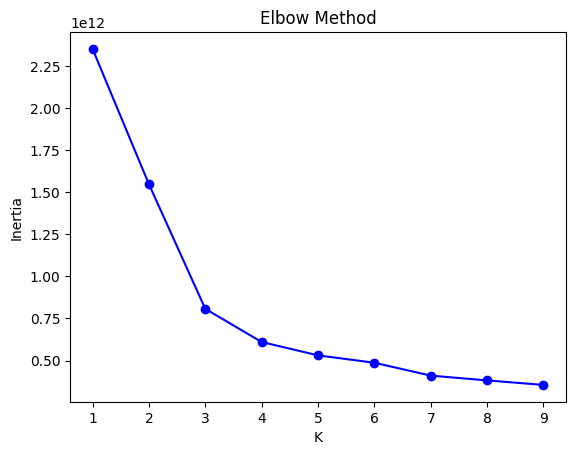

In [16]:
inertia = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

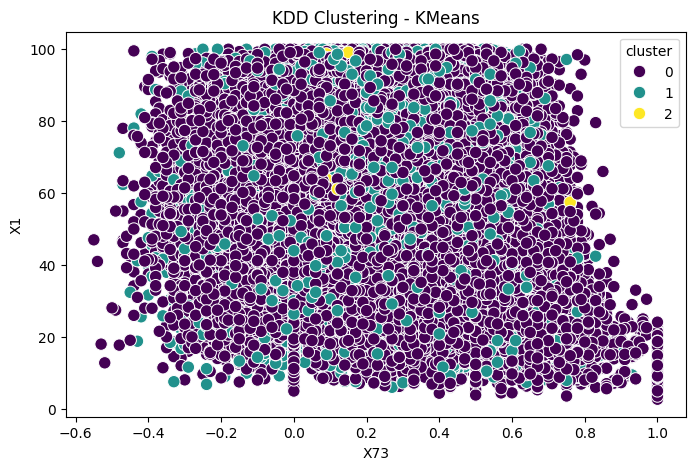

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df)


plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['X73'], y=df['X1'],
                hue=df['cluster'], palette='viridis', s=80)
plt.title("KDD Clustering - KMeans")
plt.show()


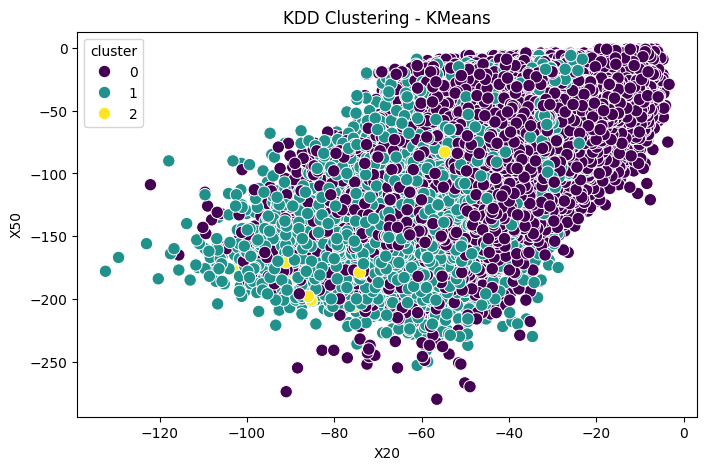

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df)


plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['X20'], y=df['X50'],
                hue=df['cluster'], palette='viridis', s=80)
plt.title("KDD Clustering - KMeans")
plt.show()

In [20]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

In [21]:
wcss

[2352589571784.7124,
 1548166418436.8289,
 807130807746.3248,
 609902668427.1405,
 530543142437.7117,
 486667973627.1373,
 410120138238.48224,
 381616205083.2943,
 354813177324.1455,
 337674871193.51685]

In [22]:
from sklearn.metrics import silhouette_score

for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    score = silhouette_score(x, labels)
    print(f"Silhouette Score for k={k}: {score:.3f}")


Silhouette Score for k=3: 0.529
Silhouette Score for k=4: 0.399


In [23]:
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)


y = kmeans.fit_predict(x)

In [24]:
print(y)

[0 0 0 ... 0 0 0]


In [27]:
import pandas as pd
from sklearn.cluster import KMeans
df = pd.read_csv("kddcup04bio.csv") 
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df.select_dtypes(include='number')) 

for cluster_num in range(3):
    cluster_df = df[df['Cluster'] == cluster_num]
    filename = f'cluster_{cluster_num + 1}_bio_dataset.csv'
    cluster_df.to_csv(filename, index=False)